## Imports

In [1]:
import cv2
import numpy as np
import torch
from torch import nn
from torch.utils.data import Dataset, WeightedRandomSampler, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from shared.early_stopping import EarlyStopping
from shared.mat_reader import MatReader
from shared.constants import CLASS_NAMES, DEVICE

## Dataset

In [2]:
from shared.normalization import ZScoreNormalizer

Datapoint = tuple[torch.Tensor, int, str]  # (patch tensor, class label, patient id)

class ElasticDataset(Dataset[Datapoint]):
    def __init__(
        self,
        mat_reader: MatReader,
        eff_fov_indices: list[int],
        train: bool = False,
    ) -> None:

        self.mat_reader = mat_reader
        self.eff_fov_indices = eff_fov_indices
        self.train = train

        self.transform = A.Compose([
            # A.ElasticTransform(
            #     alpha=10,      
            #     sigma=6, 
            #     # alpha_affine=100 * 0.03, 
            #     border_mode=cv2.BORDER_REFLECT_101,
            #     p=1.0,
            # ),
            A.RandomRotate90(p=0.5),
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.5),
            ToTensorV2() # Converts back to (C, H, W) and makes it a Tensor
        ])

        # self.normalizer = ZScoreNormalizer(mat_reader, list(range(mat_reader.get_num_fovs()))) # TODO: leakage
        self.normalizer = ZScoreNormalizer(mat_reader, eff_fov_indices) # TODO: leakage

    def __len__(self) -> int:
        return len(self.eff_fov_indices)

    def __getitem__(self, idx: int) -> Datapoint:
        eff_idx = self.eff_fov_indices[idx]

        image = self.mat_reader.images[eff_idx] # (C, H, W)
        # image = robust_minmax(image, axis=(1, 2)).astype(np.float32)
        
        if self.train:
            image = image.transpose(1, 2, 0) # (H, W, C) for albumentations
            image = self.transform(image=image)['image']
        else:
            image = torch.from_numpy(image).float()

        image = self.normalizer.normalize(image)
        
        class_label = self.mat_reader.class_labels[eff_idx]
        patient_id = self.mat_reader.patient_ids[eff_idx]

        return image, class_label, patient_id


## Model

In [3]:
import pretrained_microscopy_models as pmm
import torch.utils.model_zoo as model_zoo
from torchvision import models

class CustomModel(nn.Module):
    def __init__(self) -> None:
        super().__init__()

        # weights = models.ResNet18_Weights.DEFAULT
        # model = models.resnet18(weights=weights)
        
        model = models.resnet50(weights=None)
        url = pmm.util.get_pretrained_microscopynet_url("resnet50", "micronet")
        model.load_state_dict(model_zoo.load_url(url, map_location=DEVICE))
        
        in_features = model.fc.in_features
        num_classes = len(CLASS_NAMES)
        # model.fc = nn.Sequential(  # type: ignore[assignment]
        #     nn.BatchNorm1d(in_features), # TODO: this is similar to StandardScaler step in SVM
        #     nn.Dropout(p=0.5),
        #     nn.Linear(in_features, num_classes),
        # )
        model.fc = nn.Sequential(
            nn.BatchNorm1d(in_features),
            nn.Linear(in_features, 512),
            nn.ReLU(),
            nn.Dropout(p=0.5),
            nn.Linear(512, num_classes) 
        )

        for param in model.parameters():
            param.requires_grad = False
        for param in model.fc.parameters():
            param.requires_grad = True
        
        self.model = model
        self.fc = model.fc

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.model(x)

## StratifiedGroupKFolds

In [7]:
from shared.utils import get_n_splits

mat_reader = MatReader("/Users/james/GitHub/lampe/lampe_dataset/Full images/")
n_splits = get_n_splits(mat_reader)
print(f"# splits: {n_splits}")

from sklearn.model_selection import StratifiedGroupKFold

sgkf = StratifiedGroupKFold(n_splits=n_splits, shuffle=True)
# sgkf = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=42)

X, y, groups = mat_reader.images, mat_reader.class_labels, mat_reader.patient_ids

train_losses = [[] for _ in range(n_splits)]
train_targets = [0] * n_splits
train_preds = [0] * n_splits

val_losses = [[] for _ in range(n_splits)]
val_targets = [0] * n_splits
val_preds = [0] * n_splits

accuracies = [0] * n_splits
min_val_losses = [(9999, 10)] * n_splits # (epoch number, val loss)

for fold, (train_indices, val_indices) in enumerate(sgkf.split(X, y, groups=groups)):
    # minimum loss across epochs in the current fold
    min_val_loss = 9999
    
    train_dataset = ElasticDataset(mat_reader, eff_fov_indices=train_indices.tolist(), train=True)
    val_dataset = ElasticDataset(mat_reader, eff_fov_indices=val_indices.tolist(), train=False)

    # assumes class label ordering
    class_weights = 1.0 / np.bincount(mat_reader.class_labels[train_indices])
    sample_weights = class_weights[mat_reader.class_labels[train_indices]]
    
    sampler = WeightedRandomSampler(
        weights=sample_weights, 
        # num_samples=len(sample_weights), 
        num_samples=len(sample_weights) * 2, 
        replacement=True
    )

    train_loader = DataLoader(train_dataset, batch_size=32, sampler=sampler)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
    model = CustomModel().to(DEVICE)

    optimizer = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=0.0001, weight_decay=0.01)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=3, min_lr=1e-6
    )
    criterion = nn.CrossEntropyLoss()
    early_stopping = EarlyStopping(patience=20)

    num_epochs = 100

    for epoch in range(num_epochs):
        model.eval() # requires_grad is not enough: ".eval()" preserves BatchNorm
        model.fc.train() # enables BatchNorm and Dropout of only the classifier
        
        # epoch-level across all batches
        running_train_loss = 0.0
        epoch_train_targets = []
        epoch_train_preds = []
        
        for batch in train_loader:
            images, class_labels, patient_ids = batch
            # print(np.unique(class_labels, return_counts=True))
    
            inputs = images.to(DEVICE)
            outputs = model(inputs)
            preds = torch.argmax(outputs, dim=1)
            
            epoch_train_targets.extend(class_labels.tolist())
            epoch_train_preds.extend(preds.tolist())

            loss = criterion(outputs, class_labels.to(DEVICE))
            running_train_loss += loss.item() * images.size(0)
            
            loss.backward()
            optimizer.step()
    
        train_loss = running_train_loss / len(train_dataset)
        train_losses[fold].append(train_loss) # stores losses across all epochs

        with torch.no_grad():
            model.eval()
            
            running_val_loss = 0.0 # across batches
            epoch_val_targets = []
            epoch_val_preds = []
            
            for batch in val_loader:
                # NOTE: DataLoader converts class_labels: np.ndarray --> torch.Tensor
                images, class_labels, patient_ids = batch
                
                inputs = images.to(DEVICE)
                outputs = model(inputs)
                preds = torch.argmax(outputs, dim=1)
                
                epoch_val_targets.extend(class_labels)
                epoch_val_preds.extend(preds.tolist())

                loss = criterion(outputs, class_labels.to(DEVICE))
                running_val_loss += loss.item() * images.size(0)
                
            val_loss = running_val_loss / len(val_dataset)
            val_losses[fold].append(val_loss) # stores losses across all epochs

            # epoch with lowest validation loss
            if val_loss < min_val_loss:
                min_val_loss = val_loss
                min_val_losses[fold] = (epoch, val_loss) # for matplotlib .scatter()

                # targets and preds for this fold
                train_targets[fold] = epoch_train_targets
                train_preds[fold] = epoch_train_preds
                val_targets[fold] = epoch_val_targets
                val_preds[fold] = epoch_val_preds

                # accuracy for this fold
                acc = float(accuracy_score(val_targets[fold], val_preds[fold]))
                accuracies[fold] = acc

        
        scheduler.step(val_loss)
        early_stopping(val_loss)
        if early_stopping.early_stop:
            print(f"Early stopping triggered at epoch {epoch + 1}")
            break

        print(
            (
                f"- Fold {fold + 1}/{n_splits}"
                f"- Epoch {epoch + 1}/{num_epochs}"
                f"- Train Loss: {train_loss:.4f}"
                f"- Val Loss: {val_loss:.4f}"
                f"- Accuracy: {acc:.4f}"
            )
        )

        

# splits: 10
- Fold 1/10- Epoch 1/100- Train Loss: 1.1061- Val Loss: 0.5887- Accuracy: 0.8000
- Fold 1/10- Epoch 2/100- Train Loss: 1.0115- Val Loss: 0.5094- Accuracy: 0.8000
- Fold 1/10- Epoch 3/100- Train Loss: 0.9788- Val Loss: 0.5061- Accuracy: 0.7333
- Fold 1/10- Epoch 4/100- Train Loss: 0.8413- Val Loss: 0.5465- Accuracy: 0.7333
- Fold 1/10- Epoch 5/100- Train Loss: 0.8644- Val Loss: 0.5117- Accuracy: 0.7333
- Fold 1/10- Epoch 6/100- Train Loss: 0.8010- Val Loss: 0.4776- Accuracy: 0.8000
- Fold 1/10- Epoch 7/100- Train Loss: 1.0661- Val Loss: 0.5067- Accuracy: 0.8000
- Fold 1/10- Epoch 8/100- Train Loss: 0.8357- Val Loss: 0.5794- Accuracy: 0.8000
- Fold 1/10- Epoch 9/100- Train Loss: 0.8018- Val Loss: 0.5944- Accuracy: 0.8000
- Fold 1/10- Epoch 10/100- Train Loss: 1.3789- Val Loss: 0.6209- Accuracy: 0.8000
- Fold 1/10- Epoch 11/100- Train Loss: 1.3222- Val Loss: 0.5522- Accuracy: 0.8000
- Fold 1/10- Epoch 12/100- Train Loss: 0.8421- Val Loss: 0.5459- Accuracy: 0.8000
- Fold 1/10-

## Loss Curves

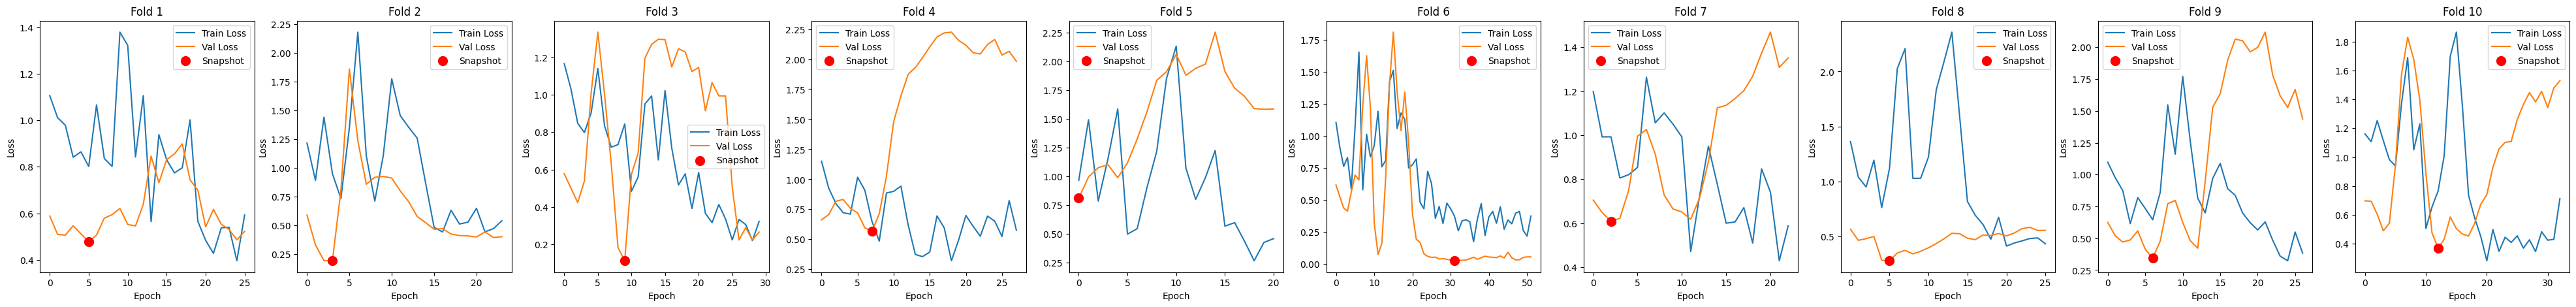

In [9]:
from matplotlib import pyplot as plt

fig, ax = plt.subplots(1, n_splits, figsize=(5 * n_splits, 5))

# fig_title = "Report"
# fig.suptitle(fig_title)

# ax[0].imshow(img)
# ax[0].set_title('Original RGB')
# ax[0].axis('off')

for i in range(n_splits):
    ax[i].plot(train_losses[i], label="Train Loss")
    ax[i].plot(val_losses[i], label="Val Loss")
    ax[i].scatter(*min_val_losses[i], color='red', s=100, zorder=5, label='Snapshot')
    ax[i].set_xlabel("Epoch")
    ax[i].set_ylabel("Loss")
    ax[i].set_title(f"Fold {i + 1}")
    ax[i].legend()


## Performance Metrics

In [10]:
for fold in range(n_splits):
    cm = confusion_matrix(train_targets[fold], train_preds[fold])
    print(f"Train Confusion Matrix (Fold {fold+1}):")
    header = "          " + "  ".join(f"{name:>10}" for name in CLASS_NAMES)
    print(header)
    for i, row in enumerate(cm):
        row_str = "  ".join(f"{v:>10}" for v in row)
        print(f"{CLASS_NAMES[i]:>10}  {row_str}")

Train Confusion Matrix (Fold 1):
                 HGC         IDC
       HGC         100          28
       IDC          18         132
Train Confusion Matrix (Fold 2):
                 HGC         IDC
       HGC         111          12
       IDC          47         108
Train Confusion Matrix (Fold 3):
                 HGC         IDC
       HGC         128          13
       IDC          26         113
Train Confusion Matrix (Fold 4):
                 HGC         IDC
       HGC         115          18
       IDC          11         132
Train Confusion Matrix (Fold 5):
                 HGC         IDC
       HGC          96          36
       IDC          36         110
Train Confusion Matrix (Fold 6):
                 HGC         IDC
       HGC         135          14
       IDC           4         123
Train Confusion Matrix (Fold 7):
                 HGC         IDC
       HGC         109          27
       IDC          32         108
Train Confusion Matrix (Fold 8):
               

In [11]:
for fold in range(n_splits):
    cm = confusion_matrix(val_targets[fold], val_preds[fold])
    print(f"Validation Confusion Matrix (Fold {fold+1} - {accuracies[fold] * 100:.2f}%):")
    header = "          " + "  ".join(f"{name:>10}" for name in CLASS_NAMES)
    print(header)
    for i, row in enumerate(cm):
        row_str = "  ".join(f"{v:>10}" for v in row)
        print(f"{CLASS_NAMES[i]:>10}  {row_str}")


Validation Confusion Matrix (Fold 1 - 80.00%):
                 HGC         IDC
       HGC           7           1
       IDC           2           5
Validation Confusion Matrix (Fold 2 - 93.33%):
                 HGC         IDC
       HGC           8           1
       IDC           0           6
Validation Confusion Matrix (Fold 3 - 100.00%):
                 HGC         IDC
       HGC           9           0
       IDC           0           5
Validation Confusion Matrix (Fold 4 - 62.50%):
                 HGC         IDC
       HGC           6           2
       IDC           4           4
Validation Confusion Matrix (Fold 5 - 20.00%):
                 HGC         IDC
       HGC           3           4
       IDC           8           0
Validation Confusion Matrix (Fold 6 - 100.00%):
                 HGC         IDC
       HGC           8           0
       IDC           0           8
Validation Confusion Matrix (Fold 7 - 62.50%):
                 HGC         IDC
       HGC        

## Report

In [12]:
print("\n--- Final Results ---")
print(
    f"Mean CV Accuracy: {np.mean(accuracies) * 100:.2f}% ± {np.std(accuracies) * 100:.2f}%"
)

print("\nGlobal Classification Report:")
print(classification_report(np.concatenate(val_targets), np.concatenate(val_preds), target_names=CLASS_NAMES)) # must take only from last epochs



--- Final Results ---
Mean CV Accuracy: 76.67% ± 23.05%

Global Classification Report:
              precision    recall  f1-score   support

         HGC       0.75      0.86      0.80        84
         IDC       0.79      0.66      0.72        70

    accuracy                           0.77       154
   macro avg       0.77      0.76      0.76       154
weighted avg       0.77      0.77      0.76       154



---

All trials with `ZScoreNormalizer`

### ResNet18 + FC 1 + Without BatchNorm

```
--- Final Results ---
Mean CV Accuracy: 57.44% ± 12.15%

Global Classification Report:
              precision    recall  f1-score   support

         HGC       0.58      0.75      0.66        84
         IDC       0.54      0.36      0.43        70

    accuracy                           0.57       154
   macro avg       0.56      0.55      0.54       154
weighted avg       0.57      0.57      0.55       154
```

(0.6000 + 0.8667 + 0.9286 + 0.7500 + 0.5333 + 0.8667 +0.8125 +0.4375 +0.7500 +0.6875)/10 = 0.72328

---

### ResNet18 + FC 1 + With BatchNorm

```
--- Final Results ---
Mean CV Accuracy: 61.39% ± 12.37%

Global Classification Report:
              precision    recall  f1-score   support

         HGC       0.64      0.64      0.64        84
         IDC       0.57      0.57      0.57        70

    accuracy                           0.61       154
   macro avg       0.61      0.61      0.61       154
weighted avg       0.61      0.61      0.61       154
```

(0.8667 + 0.9333 + 0.8571 + 0.6875 + 0.8000 + 0.6250+0.5000+0.6250+0.7500+0.7333)/10 = 0.73779

---

### MicroNet + FC 1 + With BatchNorm, Early Stopping = 10

```
--- Final Results ---
Mean CV Accuracy: 63.42% ± 9.99%

Global Classification Report:
              precision    recall  f1-score   support

         HGC       0.68      0.62      0.65        84
         IDC       0.59      0.66      0.62        70

    accuracy                           0.64       154
   macro avg       0.64      0.64      0.64       154
weighted avg       0.64      0.64      0.64       154
```

(0.8667+0.7333+0.9286+0.6250+1+0.7500+1+1+1+0.8750)/10 = 0.87786

---

### MicroNet + FC 1 + With BatchNorm, Early Stopping = 5 and Snapshot MinValLoss

```
--- Final Results ---
Mean CV Accuracy: 68.21% ± 20.30%

Global Classification Report:
              precision    recall  f1-score   support

         HGC       0.72      0.65      0.69        84
         IDC       0.63      0.70      0.66        70

    accuracy                           0.68       154
   macro avg       0.68      0.68      0.67       154
weighted avg       0.68      0.68      0.68       154
```

---

### MicroNet + FC 2 + With BatchNorm, Early Stopping = 5 and Snapshot MinValLoss

```
--- Final Results ---
Mean CV Accuracy: 74.07% ± 9.37%

Global Classification Report:
              precision    recall  f1-score   support

         HGC       0.77      0.75      0.76        84
         IDC       0.71      0.73      0.72        70

    accuracy                           0.74       154
   macro avg       0.74      0.74      0.74       154
weighted avg       0.74      0.74      0.74       154
```

---

### MicroNet + FC 2 + With BatchNorm, len(sampler) = 2, Early Stopping = 5, Epochs = 50

```
--- Final Results ---
Mean CV Accuracy: 75.38% ± 16.77%

Global Classification Report:
              precision    recall  f1-score   support

         HGC       0.76      0.77      0.77        84
         IDC       0.72      0.71      0.72        70

    accuracy                           0.75       154
   macro avg       0.74      0.74      0.74       154
weighted avg       0.75      0.75      0.75       154
```

---

### MicroNet + FC 2 + With BatchNorm, len(sampler) = 2, Early Stopping = 20, Epochs = 100 (Batch Metrics Fix)

```
--- Final Results ---
Mean CV Accuracy: 76.67% ± 23.05%

Global Classification Report:
              precision    recall  f1-score   support

         HGC       0.75      0.86      0.80        84
         IDC       0.79      0.66      0.72        70

    accuracy                           0.77       154
   macro avg       0.77      0.76      0.76       154
weighted avg       0.77      0.77      0.76       154
```

---

## Try Next

1. Re-run all FC 1, (fixed Dropout bug)
2. Running min, model save state
3. EasyEnsemble (LGC+HGC vs IDC)
4. `pytorch-grad-cam`

MicroNet - With and Without BatchNorm

FC 2

Fine Tuning

Fix ZScore Leakage